In [3]:
#pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.1 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np

In [5]:
# Find unique entries
unique_path = r"../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

In [6]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
images_raw = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_raw = []


#Folder with folders of images:
base_folder = r"../data/scrandle_padded_low_res_data"
#Meta data folders(yes, a bit inefficient. CHANGE LATER):
meta_folder = r"../data/scrandle_padded_low_res_data"
current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    #print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    images_raw.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

    if current_folder != date:
        current_folder = date
        meta_path = os.path.join(date_path, "meta.csv")
        meta_intermediate = pd.read_csv(meta_path)
        
    entry_row = meta_intermediate.loc[meta_intermediate["image_name"] == image_placement]
    metadata_raw.append({
                "price": entry_row["price"],
                "rating": entry_row["rating"],
                "year": entry_row["year"],
                "date": entry_row["date"],
                "image_name": entry_row["image_name"],
                "title": entry_row["title"],
                "subtitle": entry_row["subtitle"],
                "club": entry_row["club"],
                "country": entry_row["country"],
            })

In [7]:
ratings = []
for i in range(len(metadata_raw)):
    ratings += metadata_raw[i]["rating"].to_list()
ratings = torch.tensor(ratings) / 100

images = np.stack([img["RGB"] for img in images_raw]).astype(np.float32)
images = torch.from_numpy(images) / 255.0

images = images.permute(0,3,1,2)

In [8]:
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
num_features = model.fc.in_features
print(f"ResNet-Features: {num_features}")
model.fc = nn.Sequential(
    nn.Linear(num_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 1)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
model = model.to(device)

class ImageRatingDataset(Dataset):
    def __init__(self, ratings, images):
        if (len(ratings) != len(images)):
            raise ValueError("Error: 'ratings' and 'images is not of equal length!")
        self.ratings = ratings
        self.images = images

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        image = self.images[idx]
        rating = self.ratings[idx]

        return image, rating

dataset = ImageRatingDataset(ratings, images)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

loader = DataLoader(dataset, batch_size=16, shuffle=True)

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(10):
    total_loss = 0.0
    
    for images_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(loader):.4f}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 289MB/s]


ResNet-Features: 2048
Using Device: cuda
epoch 1: loss=0.1709
epoch 2: loss=0.1443
epoch 3: loss=0.1307
epoch 4: loss=0.1198
epoch 5: loss=0.1168
epoch 6: loss=0.1130
epoch 7: loss=0.1089
epoch 8: loss=0.1058
epoch 9: loss=0.0984
epoch 10: loss=0.0987


In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model.train()

for epoch in range(10):
    total_loss = 0.0
    
    for images_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(loader):.4f}")

epoch 1: loss=0.0393
epoch 2: loss=0.0391
epoch 3: loss=0.0372
epoch 4: loss=0.0363
epoch 5: loss=0.0349
epoch 6: loss=0.0359
epoch 7: loss=0.0344
epoch 8: loss=0.0345
epoch 9: loss=0.0337
epoch 10: loss=0.0330


In [24]:
torch.save(model.state_dict(), "model_weights")

In [10]:
model.eval()

preds_train = []
trues_train = []

with torch.no_grad():
    for images_loaded, ratings_loaded in train_loader:
        images_loaded = images_loaded.to(device)
        
        outputs = model(images_loaded).squeeze(1)

        preds_train.append(outputs.cpu())
        trues_train.append(ratings_loaded.cpu())

preds_train = torch.cat(preds_train).numpy()
trues_train = torch.cat(trues_train).numpy()


preds_test = []
trues_test = []

with torch.no_grad():
    for images_loaded, ratings_loaded in test_loader:
        images_loaded = images_loaded.to(device)
        
        outputs = model(images_loaded).squeeze(1)

        preds_test.append(outputs.cpu())
        trues_test.append(ratings_loaded.cpu())

preds_test = torch.cat(preds_test).numpy()
trues_test = torch.cat(trues_test).numpy()

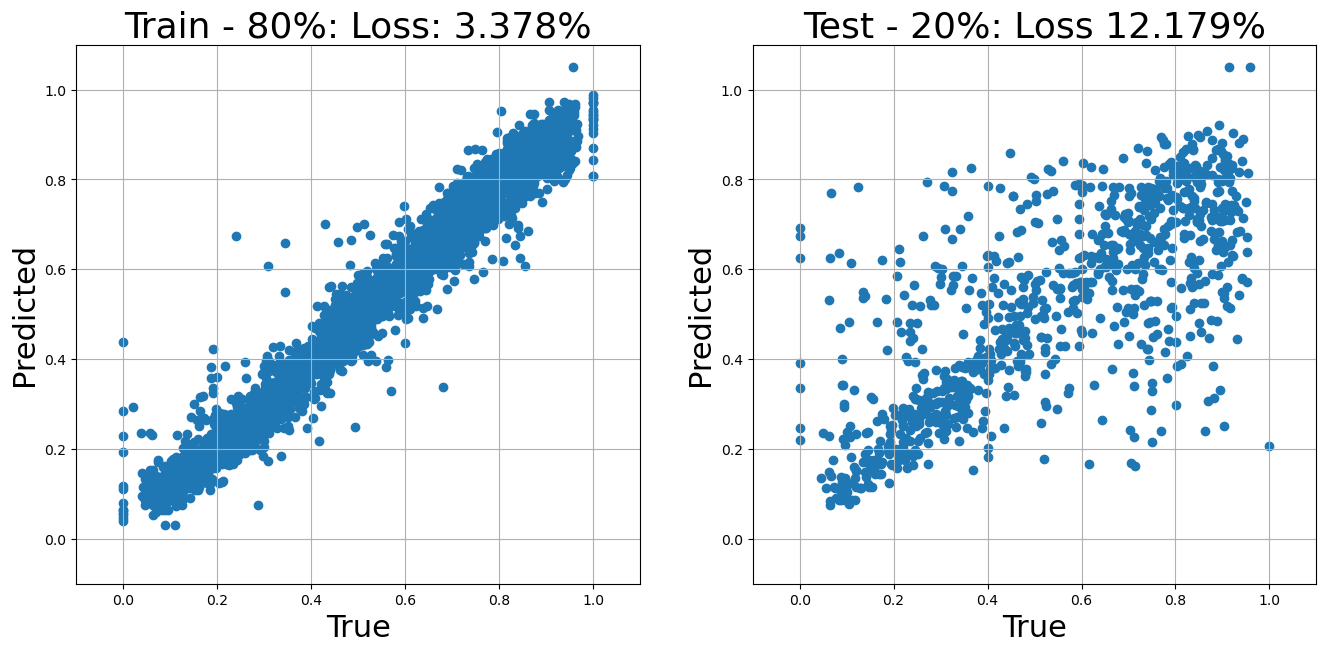

In [12]:
mask = trues_train != 0.0
loss_train = np.mean(np.abs(preds_train[mask] - trues_train[mask]))

fig, ax = plt.subplots(1,2, figsize=(16,7))
ax[0].scatter(trues_train, preds_train)
ax[0].set_xlim(-0.1,1.1)
ax[0].set_ylim(-0.1,1.1)
ax[0].set_xlabel("True", fontsize=22)
ax[0].set_ylabel("Predicted", fontsize=22)
ax[0].set_title(f"Train - 80%: Loss: {loss_train*100:.3f}%", fontsize=26)
ax[0].grid()

mask = trues_test != 0.0
loss_test = np.mean(np.abs(preds_test[mask] - trues_test[mask]))

ax[1].scatter(trues_test, preds_test)
ax[1].set_xlim(-0.1,1.1)
ax[1].set_ylim(-0.1,1.1)
ax[1].set_xlabel("True", fontsize=22)
ax[1].set_ylabel("Predicted", fontsize=22)
ax[1].set_title(f"Test - 20%: Loss {loss_test*100:.3f}%", fontsize=26)
ax[1].grid()
plt.show()